In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import datetime
from copy import deepcopy as dc
import random
from skimage import measure
import geometry_bspline as bsp_geom
import NeuralImplicit as NI
import geometry_visualisation as geom_vis
import geometry_definitions as geom_defs
import network_defs as mod
import SDF
torch.set_default_dtype(torch.float64)

## Model Visualisation and Evaluation Workflow

This workflow lets you:
- load a presaved model for a selected testcase,
- compute accuracy metrics: MAE, L_inf, boundary MAE, boundary L_inf,
- compute gradient-length error (`|\nabla u|-1`) MAE and L_inf,
- visualize ground truth, prediction, gradient-length error, prediction Laplacian error, and Laplacian of the ground truth.

In [12]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Any, Tuple, Optional

import math
import torch
import numpy as np
import matplotlib.pyplot as plt

import NeuralImplicit as NI
import network_defs as mod
import SDF

torch.set_default_dtype(torch.float64)


@dataclass
class CaseConfig:
    mode: str  # 'standard' or 'bspline'
    case_id: int
    data_gen_params: Dict[str, Any]


@dataclass
class ModelConfig:
    model_type: str  # 'siren', 'pe_relu', 'relu', 'sirelu'
    architecture: list
    checkpoint_path: str
    kwargs: Dict[str, Any]


def build_model(cfg: ModelConfig) -> torch.nn.Module:
    model_type = cfg.model_type.lower().strip()
    if model_type == "siren":
        model = mod.Siren(cfg.architecture, **cfg.kwargs)
    elif model_type == "pe_relu":
        model = mod.PE_Relu(cfg.architecture, **cfg.kwargs)
    elif model_type == "relu":
        model = mod.NeuralNetwork(cfg.architecture)
    elif model_type == "sirelu":
        model = mod.SIRELU(cfg.architecture, **cfg.kwargs)
    else:
        raise ValueError(f"Unsupported model_type: {cfg.model_type}")
    return model


def load_checkpoint(model: torch.nn.Module, checkpoint_path: str, device: torch.device) -> torch.nn.Module:
    ckpt = Path(checkpoint_path)
    if not ckpt.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt}")
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model


def gt_sdf(points: torch.Tensor, case_cfg: CaseConfig, device: torch.device) -> torch.Tensor:
    if case_cfg.mode == "standard":
        fn = case_cfg.case_id
        p = case_cfg.data_gen_params
        if fn == 0:
            return 1 - torch.sqrt(points[:, 0] ** 2 + points[:, 1] ** 2)
        if fn == 1:
            return SDF.distance_from_star_contour_vectorized(
                points,
                R=p.get("outer_radius", 1.0),
                r=p.get("inner_radius", 0.5),
                n=p.get("num_star_points", 5),
                device=device,
            )
        if fn == 4:
            return SDF.distance_from_L_shape_vectorized(points, device=device)
        if fn == 5:
            return SDF.distance_from_line_vectorized(
                points,
                angle=p.get("angle", 0.0),
                offset=p.get("offset", 0.0),
                device=device,
            )
        raise NotImplementedError(f"Unsupported standard testcase fun_num={fn}")

    if case_cfg.mode == "bspline":
        return NI.evaluate_bspline_data_gen(
            points,
            case=case_cfg.case_id,
            device=device,
            data_gen_params=case_cfg.data_gen_params,
            gt_num_curve_samples=case_cfg.data_gen_params.get("gt_num_curve_samples", 6000),
            use_refinement=case_cfg.data_gen_params.get("use_refinement", False),
        ).squeeze(-1)

    raise ValueError(f"Unsupported mode: {case_cfg.mode}")


def sample_boundary(case_cfg: CaseConfig, n: int, device: torch.device) -> torch.Tensor:
    if case_cfg.mode == "standard":
        return NI.generate_standard_boundary_points(
            num_boundary_points=n,
            fun_num=case_cfg.case_id,
            device=device,
            data_gen_params=case_cfg.data_gen_params,
        )

    return NI.generate_bspline_boundary_points(
        num_boundary_points=n,
        case=case_cfg.case_id,
        device=device,
        data_gen_params=case_cfg.data_gen_params,
        gt_num_curve_samples=case_cfg.data_gen_params.get("gt_num_curve_samples", 6000),
        use_refinement=case_cfg.data_gen_params.get("use_refinement", False),
    )


def laplacian_fd(grid_values: np.ndarray, spacing: float) -> np.ndarray:
    d2x = np.gradient(np.gradient(grid_values, spacing, axis=0), spacing, axis=0)
    d2y = np.gradient(np.gradient(grid_values, spacing, axis=1), spacing, axis=1)
    return d2x + d2y


def _laplacian_random_autograd(model: torch.nn.Module, points: torch.Tensor) -> torch.Tensor:
    points = points.clone().detach().requires_grad_(True)
    pred = model(points).view(-1)
    grads = torch.autograd.grad(
        outputs=pred,
        inputs=points,
        grad_outputs=torch.ones_like(pred),
        create_graph=True,
        retain_graph=True,
    )[0]

    d2udx2 = torch.autograd.grad(
        outputs=grads[:, 0],
        inputs=points,
        grad_outputs=torch.ones_like(grads[:, 0]),
        create_graph=False,
        retain_graph=True,
    )[0][:, 0]
    d2udy2 = torch.autograd.grad(
        outputs=grads[:, 1],
        inputs=points,
        grad_outputs=torch.ones_like(grads[:, 1]),
        create_graph=False,
        retain_graph=False,
    )[0][:, 1]
    return d2udx2 + d2udy2


def evaluate_model(
    model: torch.nn.Module,
    case_cfg: CaseConfig,
    *,
    n_eval: int = 30000,
    n_boundary: int = 10000,
    n_grad_eval: int = 30000,
    n_lap_eval: int = 12000,
    n_grid: int = 220,
    eval_range: Tuple[float, float] = (-1.005, 1.005),
    device: Optional[torch.device] = None,
    seed: Optional[int] = None,
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    x_min, x_max = eval_range

    with torch.no_grad():
        eval_pts = (x_max - x_min) * torch.rand(n_eval, 2, device=device) + x_min
        gt_eval = gt_sdf(eval_pts, case_cfg, device=device).view(-1, 1)
        pred_eval = model(eval_pts)
        abs_err_samples = torch.abs(pred_eval - gt_eval)
        mae = abs_err_samples.mean().item()
        linf = abs_err_samples.max().item()

        bnd_pts = sample_boundary(case_cfg, n_boundary, device)
        bnd_pred = model(bnd_pts)
        bnd_abs = torch.abs(bnd_pred)
        bnd_mae = bnd_abs.mean().item()
        bnd_linf = bnd_abs.max().item()

    grad_pts = (x_max - x_min) * torch.rand(n_grad_eval, 2, device=device) + x_min
    grad_pts.requires_grad_(True)
    pred_grad_eval = model(grad_pts)
    grads = torch.autograd.grad(
        outputs=pred_grad_eval,
        inputs=grad_pts,
        grad_outputs=torch.ones_like(pred_grad_eval),
        create_graph=False,
        retain_graph=False,
    )[0]
    grad_len_err = torch.abs(torch.linalg.norm(grads, dim=1) - 1.0)
    grad_len_mae = grad_len_err.mean().item()
    grad_len_linf = grad_len_err.max().item()

    lap_pts = (x_max - x_min) * torch.rand(n_lap_eval, 2, device=device) + x_min
    lap_pred_samples = _laplacian_random_autograd(model, lap_pts)
    lap_abs_samples = torch.abs(lap_pred_samples)
    lap_abs_mae = lap_abs_samples.mean().item()
    lap_abs_linf = lap_abs_samples.max().item()

    x = np.linspace(x_min, x_max, n_grid)
    y = np.linspace(x_min, x_max, n_grid)
    X, Y = np.meshgrid(x, y)
    grid = np.stack([X.ravel(), Y.ravel()], axis=1)
    grid_t = torch.tensor(grid, dtype=torch.float64, device=device)

    grid_t_grad = grid_t.clone().detach().requires_grad_(True)
    pred_grid = model(grid_t_grad)
    grads_grid = torch.autograd.grad(
        outputs=pred_grid,
        inputs=grid_t_grad,
        grad_outputs=torch.ones_like(pred_grid),
        create_graph=False,
        retain_graph=False,
    )[0]

    with torch.no_grad():
        gt_grid = gt_sdf(grid_t, case_cfg, device=device).view(-1, 1)
        pred_grid_np = pred_grid.detach().cpu().numpy().reshape(n_grid, n_grid)
        gt_grid_np = gt_grid.detach().cpu().numpy().reshape(n_grid, n_grid)

    abs_err = np.abs(pred_grid_np - gt_grid_np)
    grad_len_err_map = torch.abs(torch.linalg.norm(grads_grid, dim=1) - 1.0).detach().cpu().numpy().reshape(n_grid, n_grid)

    spacing = (x_max - x_min) / (n_grid - 1)
    lap_gt = laplacian_fd(gt_grid_np, spacing)
    lap_pred = laplacian_fd(pred_grid_np, spacing)
    lap_err_vs_zero = np.abs(lap_pred)

    metrics = {
        "MAE": mae,
        "L_inf": linf,
        "boundary_MAE": bnd_mae,
        "boundary_L_inf": bnd_linf,
        "grad_length_error_MAE": grad_len_mae,
        "grad_length_error_L_inf": grad_len_linf,
        "laplacian_abs_MAE": lap_abs_mae,
        "laplacian_abs_L_inf": lap_abs_linf,
    }

    fields = {
        "X": X,
        "Y": Y,
        "gt": gt_grid_np,
        "pred": pred_grid_np,
        "abs_err": abs_err,
        "grad_len_err": grad_len_err_map,
        "lap_gt": lap_gt,
        "lap_pred_abs": lap_err_vs_zero,
    }

    return metrics, fields


def plot_evaluation(fields: Dict[str, np.ndarray], title_prefix: str = ""):
    X, Y = fields["X"], fields["Y"]
    gt = fields["gt"]
    pred = fields["pred"]
    abs_err = fields["abs_err"]
    grad_len_err = fields["grad_len_err"]
    lap_pred_abs = fields["lap_pred_abs"]
    lap_gt = fields["lap_gt"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)

    c0 = axes[0, 0].contourf(X, Y, gt, levels=80, cmap="RdBu_r")
    axes[0, 0].contour(X, Y, gt, levels=[0], colors="k", linewidths=1.0)
    axes[0, 0].set_title("Ground Truth SDF")
    fig.colorbar(c0, ax=axes[0, 0])

    c1 = axes[0, 1].contourf(X, Y, pred, levels=80, cmap="RdBu_r")
    axes[0, 1].contour(X, Y, pred, levels=[0], colors="k", linewidths=1.0)
    axes[0, 1].set_title("Model Prediction")
    fig.colorbar(c1, ax=axes[0, 1])

    vmax = np.percentile(abs_err, 99.0)
    if not np.isfinite(vmax) or vmax <= 0.0:
        vmax = np.max(abs_err) if np.max(abs_err) > 0.0 else 1e-12
    c2 = axes[0, 2].contourf(X, Y, abs_err, levels=80, cmap="magma", vmin=0.0, vmax=vmax)
    axes[0, 2].set_title("Absolute Prediction Error (clipped at 99th pct)")
    fig.colorbar(c2, ax=axes[0, 2])

    c3 = axes[1, 0].contourf(X, Y, grad_len_err, levels=80, cmap="viridis")
    axes[1, 0].set_title("Gradient-Length Error: ||grad(u_pred)|| - 1|")
    fig.colorbar(c3, ax=axes[1, 0])

    c4 = axes[1, 1].contourf(X, Y, lap_pred_abs, levels=80, cmap="plasma")
    axes[1, 1].set_title("Laplacian Absolute Value: |lap(u_pred)|")
    fig.colorbar(c4, ax=axes[1, 1])

    c5 = axes[1, 2].contourf(X, Y, lap_gt, levels=80, cmap="coolwarm")
    axes[1, 2].set_title("Laplacian of Ground Truth")
    fig.colorbar(c5, ax=axes[1, 2])

    for ax in axes.ravel():
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.suptitle(title_prefix + " Model Evaluation", fontsize=16)
    plt.show()

C:\Users\csapo\AppData\Local\Temp\ipykernel_21804\4262400482.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt, map_location=device)


Evaluation metrics (random-sampled):
  MAE: 1.278739e-04
  L_inf: 1.443700e-03
  boundary_MAE: 1.051147e-04
  boundary_L_inf: 9.021334e-04
  grad_length_error_MAE: 3.602711e-02
  grad_length_error_L_inf: 6.871765e-01
  laplacian_abs_MAE: 1.935058e+01
  laplacian_abs_L_inf: 9.758082e+01


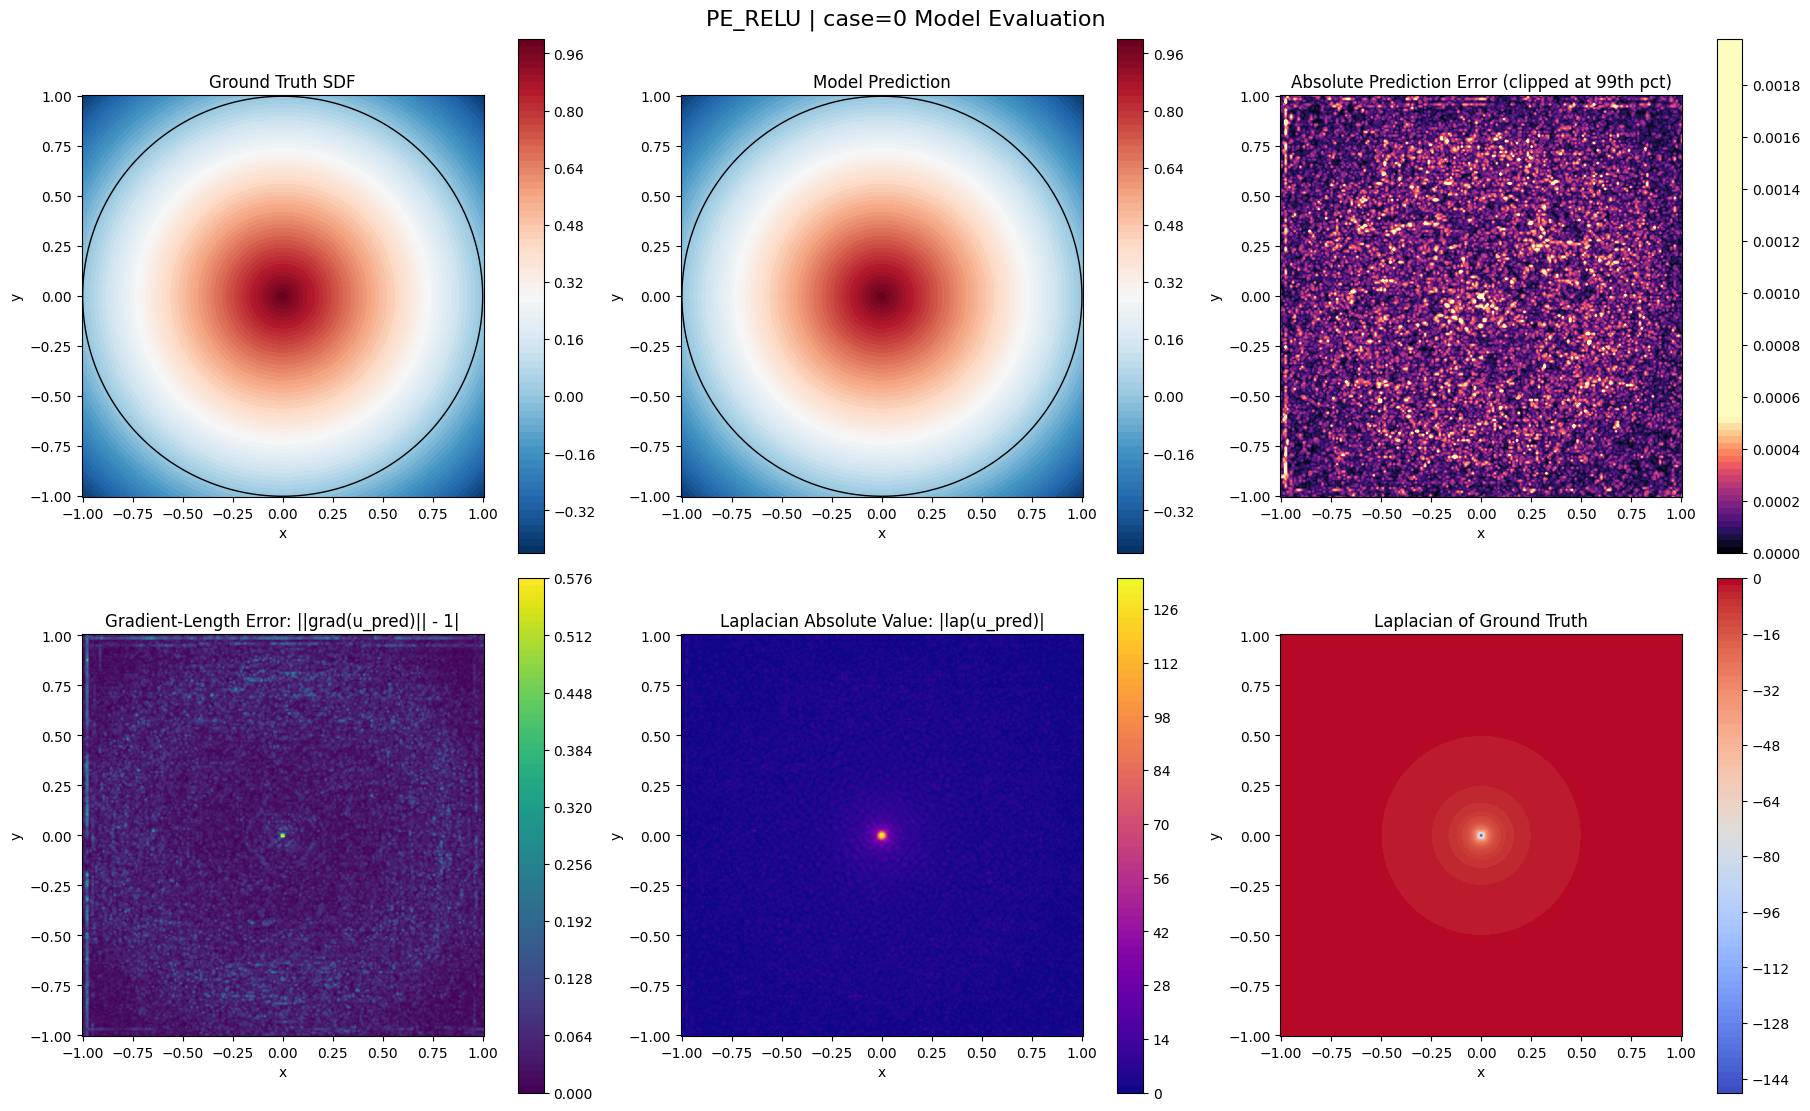

In [78]:
# ---------------------- User configuration ----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Standard testcases: 0=circle, 1=star, 4=L-shape, 5=line
CASE = CaseConfig(
    mode="standard",
    case_id=0,
    data_gen_params={
        "angle": math.pi / 6,
        "offset": 0.0,
        "outer_radius": 1.0,
        "inner_radius": 0.5,
        "num_star_points": 5,
        "range_min": -1.005,
        "range_max": 1.005,
    },
)

# MODEL = ModelConfig(
#     model_type="siren",
#     architecture=[2, 256, 256, 256, 1],
#     checkpoint_path=r".\model\2.pth",
#     kwargs={
#         "outermost_linear": True,
#         "first_omega_0": 80,
#         "hidden_omega_0": 120,
#     },
# )
# MODEL = ModelConfig(
#     model_type="ReLu",
#     architecture=[2, 256, 256, 256, 256, 1],
#     checkpoint_path=r".\model\2.pth",
#     kwargs={},
# )

#Example for PE-ReLU:
MODEL = ModelConfig(
    model_type="pe_relu",
    architecture=[2, 256, 256, 256, 256, 1],
    checkpoint_path=r".\model\0.pth",
    kwargs={"num_freqs": 10, "include_input": True},
)

# ---------------------- Run evaluation ----------------------
model = build_model(MODEL)
model = load_checkpoint(model, MODEL.checkpoint_path, DEVICE)

metrics, fields = evaluate_model(
    model,
    CASE,
    n_eval=30000,
    n_boundary=10000,
    n_grad_eval=30000,
    n_lap_eval=12000,
    n_grid=220,
    eval_range=(-1.005, 1.005),
    device=DEVICE,
    seed=42,
)

print("Evaluation metrics (random-sampled):")
for key, value in metrics.items():
    print(f"  {key}: {value:.6e}")

plot_evaluation(fields, title_prefix=f"{MODEL.model_type.upper()} | case={CASE.case_id}")

## Batch Evaluation for Multiple Saved Models

Use this block to evaluate N models stored as `k.pth` in a folder (same architecture and model type for all). It prints metrics for each model and does not create plots.

In [81]:
from pathlib import Path
import pandas as pd
import torch

# ---------------------- Batch evaluation config ----------------------
MODEL_FOLDER = Path(r".\model")   # folder containing 0.pth, 1.pth, ..., k.pth
NUM_MODELS = 3                      # evaluate models 0..NUM_MODELS-1
START_INDEX = 0

# All models in the same batch are assumed to have the same type.
# Set it explicitly here to match the saved checkpoints in the folder.
BATCH_MODEL_TYPE = MODEL.model_type
BATCH_ARCHITECTURE = MODEL.architecture
BATCH_KWARGS = dict(MODEL.kwargs)

ARCHITECTURE_BY_MODEL = {}

KWARGS_BY_MODEL = {
    0: {"num_freqs": 10, "include_input": True},
    1: {"num_freqs": 10, "include_input": True},
    2: {"num_freqs": 10, "include_input": True},
    3: {"num_freqs": 10, "include_input": True},
    4: {"num_freqs": 10, "include_input": True},
    5: {"num_freqs": 20, "include_input": True},
}

FIRST_OMEGA_0_BY_MODEL = {0: 15, 1: 15, 2: 15, 3: 30, 4: 15, 5: 15}
HIDDEN_OMEGA_0_BY_MODEL = {0: 30, 1: 30, 2: 30, 3: 30, 4: 30, 5: 30}


def sanitize_kwargs_for_model_type(model_type: str, kwargs: dict) -> dict:
    model_type = model_type.lower().strip()
    allowed_keys = {
        "siren": {"outermost_linear", "first_omega_0", "hidden_omega_0"},
        "pe_relu": {"num_freqs", "include_input"},
        "relu": set(),
        "sirelu": {"first_omega_0"},
    }
    allowed = allowed_keys.get(model_type, set())
    return {k: v for k, v in kwargs.items() if k in allowed}


def infer_pe_relu_num_freqs_from_state(state_dict: dict, in_features: int, include_input: bool):
    # PE_ReLU first Linear layer is expected at 'net.0.weight' with shape [hidden, encoded_features].
    w0 = state_dict.get("net.0.weight", None)
    if w0 is None:
        return None
    encoded_features = int(w0.shape[1])
    include_term = 1 if include_input else 0
    denom = 2 * in_features
    numer = encoded_features - in_features * include_term
    if denom <= 0 or numer < 0 or numer % denom != 0:
        return None
    return numer // denom


def build_and_load_model_from_state(
    model_type: str,
    architecture: list,
    kwargs: dict,
    state: dict,
    device: torch.device,
):
    model_type_norm = model_type.lower().strip()

    # First attempt: use kwargs exactly as configured.
    candidate_kwargs = [dict(kwargs)]

    # For PE_ReLU, add checkpoint-inferred candidates so mismatched num_freqs can recover automatically.
    if model_type_norm == "pe_relu":
        in_features = int(architecture[0])
        include_candidates = [bool(kwargs.get("include_input", True)), not bool(kwargs.get("include_input", True))]

        for include_input in include_candidates:
            inferred_num_freqs = infer_pe_relu_num_freqs_from_state(state, in_features, include_input)
            if inferred_num_freqs is None:
                continue
            cand = dict(kwargs)
            cand["include_input"] = bool(include_input)
            cand["num_freqs"] = int(inferred_num_freqs)
            if cand not in candidate_kwargs:
                candidate_kwargs.append(cand)

    last_exc = None
    for cand_kwargs in candidate_kwargs:
        cfg = ModelConfig(
            model_type=model_type,
            architecture=architecture,
            checkpoint_path="",
            kwargs=cand_kwargs,
        )
        model = build_model(cfg)
        try:
            model.load_state_dict(state)
            model.to(device)
            model.eval()
            return model, cand_kwargs
        except RuntimeError as exc:
            last_exc = exc

    raise last_exc


batch_results = []

print(f"Batch evaluation in folder: {MODEL_FOLDER.resolve()}")
for k in range(START_INDEX, START_INDEX + NUM_MODELS):
    ckpt_path = MODEL_FOLDER / f"{k}.pth"

    if not ckpt_path.exists():
        print(f"Model {k}: checkpoint missing -> {ckpt_path}")
        continue

    architecture_k = ARCHITECTURE_BY_MODEL.get(k, BATCH_ARCHITECTURE)
    kwargs_k = dict(BATCH_KWARGS)
    kwargs_k.update(KWARGS_BY_MODEL.get(k, {}))

    batch_type_norm = BATCH_MODEL_TYPE.lower().strip()
    if batch_type_norm in ("siren", "sirelu"):
        if k in FIRST_OMEGA_0_BY_MODEL:
            kwargs_k["first_omega_0"] = FIRST_OMEGA_0_BY_MODEL[k]
    if batch_type_norm == "siren":
        if k in HIDDEN_OMEGA_0_BY_MODEL:
            kwargs_k["hidden_omega_0"] = HIDDEN_OMEGA_0_BY_MODEL[k]

    kwargs_k = sanitize_kwargs_for_model_type(BATCH_MODEL_TYPE, kwargs_k)

    state = torch.load(ckpt_path, map_location=DEVICE)

    try:
        model_k, kwargs_loaded = build_and_load_model_from_state(
            model_type=BATCH_MODEL_TYPE,
            architecture=architecture_k,
            kwargs=kwargs_k,
            state=state,
            device=DEVICE,
        )
    except RuntimeError as exc:
        print(f"Model {k}: load failed -> {exc}")
        continue

    if kwargs_loaded != kwargs_k:
        print(f"Model {k}: adjusted kwargs for loading -> {kwargs_loaded}")
        kwargs_k = kwargs_loaded

    model_cfg_k = ModelConfig(
        model_type=BATCH_MODEL_TYPE,
        architecture=architecture_k,
        checkpoint_path=str(ckpt_path),
        kwargs=kwargs_k,
    )

    metrics_k, _ = evaluate_model(
        model_k,
        CASE,
        n_eval=30000,
        n_boundary=10000,
        n_grad_eval=30000,
        n_lap_eval=12000,
        n_grid=220,
        eval_range=(-1.005, 1.005),
        device=DEVICE,
        seed=42,
    )

    batch_results.append((k, metrics_k, model_cfg_k, kwargs_k))

if len(batch_results) == 0:
    print("No models were evaluated.")
else:
    metric_order = [
        "MAE",
        "L_inf",
        "boundary_MAE",
        "boundary_L_inf",
        "grad_length_error_MAE",
        "grad_length_error_L_inf",
        "laplacian_abs_MAE",
        "laplacian_abs_L_inf",
    ]

    print("\nBatch evaluation metrics (random-sampled):")
    for model_idx, metric_dict, model_cfg_k, kwargs_k in batch_results:
        omega_info = ""
        if "first_omega_0" in kwargs_k or "hidden_omega_0" in kwargs_k:
            omega_info = f", first_omega_0={kwargs_k.get('first_omega_0', 'NA')}, hidden_omega_0={kwargs_k.get('hidden_omega_0', 'NA')}"
        print(f"\nModel {model_idx} ({model_idx}.pth, type={model_cfg_k.model_type}, arch={model_cfg_k.architecture}{omega_info}):")
        for metric_name in metric_order:
            print(f"  {metric_name}: {metric_dict[metric_name]:.6e}")

    rows = []
    for model_idx, metric_dict, model_cfg_k, kwargs_k in batch_results:
        row = {
            "model_idx": model_idx,
            "checkpoint": f"{model_idx}.pth",
            "model_type": model_cfg_k.model_type,
            "architecture": str(model_cfg_k.architecture),
            "first_omega_0": kwargs_k.get("first_omega_0", ""),
            "hidden_omega_0": kwargs_k.get("hidden_omega_0", ""),
        }
        for metric_name in metric_order:
            row[metric_name] = metric_dict[metric_name]
        rows.append(row)

    df_metrics = pd.DataFrame(rows)

    print("\nDataFrame preview:")
    print(df_metrics.to_string(index=False))

    try:
        df_metrics.to_clipboard(index=False, excel=True)
        print("\nCopied to clipboard in Excel-compatible format.")
    except Exception as exc:
        print(f"\nClipboard export failed: {exc}")

    csv_path = MODEL_FOLDER / "batch_metrics_excel.csv"
    df_metrics.to_csv(csv_path, sep=";", index=False, float_format="%.6e")
    print(f"Saved semicolon CSV for Excel: {csv_path}")

    print("\nExcel-ready TSV (tab-separated):")
    headers = ["model_idx", "checkpoint", "model_type", "architecture", "first_omega_0", "hidden_omega_0"] + metric_order
    print("\t".join(headers))
    for _, row in df_metrics.iterrows():
        values = [
            str(int(row["model_idx"])),
            str(row["checkpoint"]),
            str(row["model_type"]),
            str(row["architecture"]),
            str(row["first_omega_0"]),
            str(row["hidden_omega_0"]),
        ] + [f"{row[m]:.6e}" for m in metric_order]
        print("\t".join(values))

Batch evaluation in folder: C:\Egyetem\Kutatás\NeuralIGA\Neural iga\NeuralSDF\model


C:\Users\csapo\AppData\Local\Temp\ipykernel_21804\1125699857.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=DEVICE)



Batch evaluation metrics (random-sampled):

Model 0 (0.pth, type=pe_relu, arch=[2, 256, 256, 256, 256, 1]):
  MAE: 1.278739e-04
  L_inf: 1.443700e-03
  boundary_MAE: 1.051147e-04
  boundary_L_inf: 9.021334e-04
  grad_length_error_MAE: 3.602711e-02
  grad_length_error_L_inf: 6.871765e-01
  laplacian_abs_MAE: 1.935058e+01
  laplacian_abs_L_inf: 9.758082e+01

Model 1 (1.pth, type=pe_relu, arch=[2, 256, 256, 256, 256, 1]):
  MAE: 1.535833e-04
  L_inf: 1.194106e-03
  boundary_MAE: 1.226956e-04
  boundary_L_inf: 8.865883e-04
  grad_length_error_MAE: 3.782126e-02
  grad_length_error_L_inf: 6.127024e-01
  laplacian_abs_MAE: 1.867881e+01
  laplacian_abs_L_inf: 8.495953e+01

Model 2 (2.pth, type=pe_relu, arch=[2, 256, 256, 256, 256, 1]):
  MAE: 1.010525e-04
  L_inf: 2.999063e-03
  boundary_MAE: 1.200436e-04
  boundary_L_inf: 9.814192e-04
  grad_length_error_MAE: 1.462530e-02
  grad_length_error_L_inf: 8.908701e-01
  laplacian_abs_MAE: 4.411982e+00
  laplacian_abs_L_inf: 9.995631e+01

DataFrame 